# Amazon Stock Forecasting in PyTorch with LSTM

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from copy import deepcopy as dc

In [75]:
# Check that MPS is available on Apple M series chip
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    device = torch.device("mps")
    print("MPS is available on this machine.")

MPS is available on this machine.


In [76]:
data = pd.read_csv('AMZN.csv')
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [77]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,6516.000000,6516.000000,6516.000000,6516.000000,6516.000000,6.516000e+03
mean,31.611626,31.991995,31.193432,31.599740,31.599740,1.425338e+08
std,48.095343,48.659651,47.464476,48.060258,48.060258,1.401619e+08
min,0.070313,0.072396,0.065625,0.069792,0.069792,9.744000e+06
25%,1.998875,2.028500,1.964750,2.001250,2.001250,6.888182e+07
50%,6.456750,6.535500,6.353250,6.444250,6.444250,1.059050e+08
75%,38.451375,38.688000,38.203001,38.464625,38.464625,1.607700e+08
max,187.199997,188.654007,184.839493,186.570496,186.570496,2.086584e+09


/var/folders/38/vqm_jnw91nq8j7r_g3t7rcz40000gp/T/ipykernel_25355/1575971661.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data[col] for col in columns_to_plot], labels=columns_to_plot)


Text(0, 0.5, 'Price')

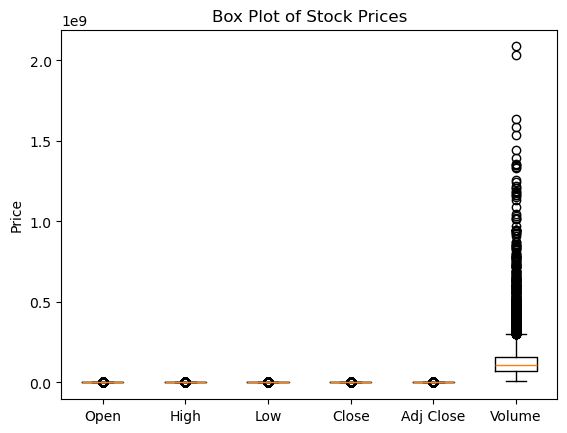

In [78]:
columns_to_plot = data.select_dtypes(include='number').columns # we can't plot the date column
plt.boxplot([data[col] for col in columns_to_plot], labels=columns_to_plot)
plt.title('Box Plot of Stock Prices')
plt.ylabel('Price')

Our task would be to forecast the closing price of the Amazon share on each date. For now let us see how the trend looks like.

Text(0, 0.5, 'Price')

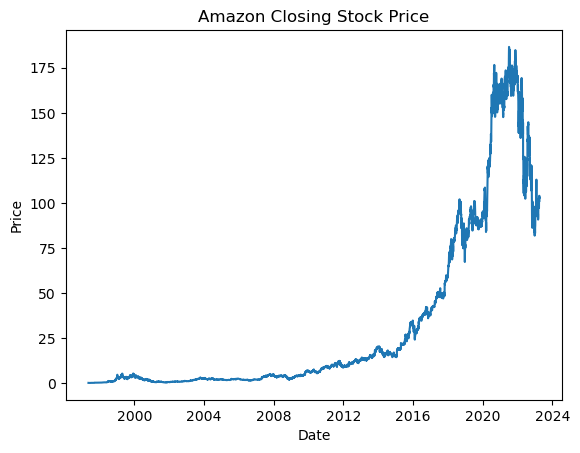

In [79]:
data = data[['Date', 'Close']]
data['Date'] = pd.to_datetime(data['Date'])
plt.plot(data['Date'], data['Close'])
plt.title('Amazon Closing Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')

## Data preprocessing for training with LSTM
Our objective is to predict the closing value of the share based on the time history of closing value previous days. The number of features is 1, which is the closing value of the share. And number of samples is the number of days in the dataset.

Since LSTM works with sequence of data, we need to convert the each sample is a sequence of past Close values. We can choose the number of days to look back and use that as the input to the LSTM model. And the number of days to looks back decides the number of LSTM cells in the model.

In [80]:
def prepare_dataframe_for_lstm(df, n_steps):
    df = dc(df)
    df.set_index('Date', inplace=True)

    for i in range(1, n_steps + 1):
        df[f'Close(t-{i})'] = df['Close'].shift(i)

    df.dropna(inplace=True)
    return df

In [81]:
lookback = 7
shifted_df = prepare_dataframe_for_lstm(data, lookback)
shifted_df.head()

,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
Date,,,,,,,,
1997-05-27,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1997-05-28,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
1997-05-29,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
1997-05-30,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
1997-06-02,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354


* Number of features: 1 (Close value of the share). Each feature is not a number but a sequence of numbers. Each LSTM cells get one number from the sequence as input.
* Number of samples: Number of days in the dataset
* Number of days to look back: Decide the number of LSTM cells in the model : 7
* Close or Close(t) is the target value and the output of the final LSTM cell.

## Multi-step forecasting
Given a date, Cell 1 will take Close(t-7) and predict Close(t-6), Cell 2 will take Close(t-6) and predict Close(t-5) and so on. The final cell will take Close(t-1) and predict Close(t). This is multistep forecasting, you care about predictions at intermediate timesteps (e.g., forecasting multiple days into the future).

https://www.kaggle.com/code/nicapotato/keras-timeseries-multi-step-multi-output

# Single-step forecasting
In this case, we are more interested in predicting the closing price of the stock for the next day. So we will use a single step forecasting. meaning all the outputs of the intermediate cells will be discarded as garbage. Only the output of the final cell will be used to compute the loss and update the weights. For obvious reasons, this is much easier to train and cheaper to compute.

## Scaling the data

In [82]:
from sklearn.preprocessing import MinMaxScaler

In [83]:
shifted_df_as_np = shifted_df.to_numpy() # ignore the date column

scaler = MinMaxScaler(feature_range=(-1, 1)) # between -1 and 1
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)

shifted_df_as_np[0]

array([-0.99991063, -0.99995531, -1.        , -0.99998325, -0.99987154,
       -0.99983244, -0.99982128, -0.99969839])

In [84]:
X = shifted_df_as_np[:, 1:] # everything except the first column which is the output
y = shifted_df_as_np[:, 0] # the first column is the output or the Close (t)

X.shape, y.shape

((6509, 7), (6509,))

In [85]:
X = np.flip(X, axis=1).copy() # reverse the order of the columns because we want the most recent data to be last LTSM cell and the oldest data to be the first LSTM cell
# here copy is used because
# np.flip flips the array along the specified axis but doesn’t make a copy. Instead, it creates a view with reversed strides.
# This means that the original array and the flipped array share the same memory.
# PyTorch does not support tensors with negative strides, so you’ll need to explicitly make a copy of the flipped array.
# https://stackoverflow.com/a/73275034/14598633
X[0]

array([-0.99969839, -0.99982128, -0.99983244, -0.99987154, -0.99998325,
       -1.        , -0.99995531])

### Dataset split
* Training: 95%
* Testing: 5%

In [86]:
split_index = int(0.95 * len(X))
split_index

6183

In [87]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7), (326, 7), (6183,), (326,))

PyTorch requires the input data for RNNs, including LSTMs, to be in 3D tensor format: [samples, timesteps, features]. Since we have only one feature, the closing price, the number of features is 1, so our tensor will need to have the shape [samples, timesteps, 1].

In [88]:
# Reshape for PyTorch
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

y_train = y_train.reshape((y_train.shape[0], 1))
y_test = y_test.reshape((y_test.shape[0], 1))

# Check the shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7, 1), (326, 7, 1), (6183, 1), (326, 1))

In [89]:
# Convert the data to PyTorch tensors
X_train = torch.tensor(X_train).float()
X_test = torch.tensor(X_test).float()

y_train = torch.tensor(y_train).float()
y_test = torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([6183, 7, 1]),
 torch.Size([326, 7, 1]),
 torch.Size([6183, 1]),
 torch.Size([326, 1]))

## Dataset
Generally in Pytorch we work with datasets rather than raw tensors.

In [90]:
from torch.utils.data import Dataset

# This is boilerplate code for creating a PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [91]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

In [92]:
from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# shuffle=True 
# shuffling the test dataset is unnecessary because testing is purely for evaluation, not for learning. So we just avoid the overhead of shuffling the test data.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Each batch will generate an input tensor of [batch_size, timesteps, 1] and output tensor of [batch_size, 1].

In [93]:
for _, batch in enumerate(train_loader):
    X_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(X_batch.shape, y_batch.shape)
    break

torch.Size([16, 7, 1]) torch.Size([16, 1])


# LSTM model
* Single layer LSTM
    * Input → LSTM → Dense → Output
    * Within a single LSTM layer, there are multiple cells. 
    * Each cell processes one timestep of the input sequence in chronological order.
    * In Pytorch, `nn.LSTM(input_size, hidden_size)`
    Each cell has a hidden state and a cell state. The hidden state is passed to the next cell and the cell state is passed to the next time step.

## Stacked LSTM
* We can stack multiple LSTM akin to hidden layers to increase the model capacity.
* First LSTM Layer: Takes the actual input sequence. and Outputs hidden states for all time steps. So, if actual input sequence is 7 in shape, the output hidden state will be 7 too.
* Second LSTM Layer: Takes the all hidden states of the first LSTM layer as input and outputs the hidden states for all time steps. Actual inputs are not used here. Just like hidden layers in a feedforward neural network, the the inputs from previous hidden layer are used as input to the next hidden layer not the actual input to the NN. each layer is a feature transformation. 

![stacked_LSTM.png](https://machinelearningmastery.com/wp-content/uploads/2017/07/architecture_stacked_lstm.png)
* In this example, we will use a stacked LSTM as PyTorch by default allow for stacked LSTM. 
    * `nn.LSTM(input_size, hidden_size, num_stacked_layers)`. The default value of num_stacked_layers is 1, meaning a single LSTM layer.


* The function of dense layer in the end is to convert the high-dimensional features learned by earlier layers (like convolutional layers in CNNs or hidden states in LSTMs) and map them to the desired output. The output can be a single value or a vector of values. In our case, it will be a single value, the predicted closing price of the stock.



In [94]:
# A stacked LSTM model
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        """
        input_size: number of features in the input data
        hidden_size: # number of hidden units in the LSTM cell, or dimension of h_t and c_t are 2d matrices of shape (batch_size, hidden_size)
            * for stacked LSTM, pytorch adds another dimension to h_t and c_t, so the shape becomes (num_stacked_layers, batch_size, hidden_size).
            * This simplfies the internal working of stacked LSTM as we need fewer matrices.
        num_stacked_layers: number of LSTM in the stacked LSTM
        """
        super().__init__()
        self.hidden_size = hidden_size 
        
        self.num_stacked_layers = num_stacked_layers 
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers, batch_first=True)
        # batch_first=True makes the input tensor format [batch_size, timesteps, input_features], to match our dataset format. 
        # By default, it is [timesteps, batch_size, input_features]

        self.fc = nn.Linear(hidden_size, 1) # convert high-dimensional hidden state to a single output for Close(t) prediction, thus output size is 1

    def forward(self, x):
        batch_size = x.size(0)
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device) # short term memory
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device) # long term memory

        out, _ = self.lstm(x, (h0, c0)) #  out shape: [batch_size, timesteps, hidden_size]
        out = self.fc(out[:, -1, :]) # input tensor has format : [batch_size, timesteps, 1], we need the last or -1th timestep, which is our Close(t)
        # out shape after fc: [batch_size, 1] meaning Close(t) prediction for each sample in the batch.
        return out

In [95]:
model = LSTM(1, 4, 1).to(device) # 1 feature, 4 hidden units, no stacking
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

## Training loop

In [96]:
def train_one_epoch():
    # All are global variables so no need to pass them as arguments
    model.train(True) # set the model to training mode
    print(f"Epoch: {epoch + 1}")
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader): # get a batch of data
        X_batch, y_batch = batch[0].to(device), batch[1].to(device) # send the batch to the device

        output = model(X_batch) # by default model.forward() is called because of nn.Module inheritance
        loss = loss_function(output, y_batch) # returns the loss as a tensor, as a scalar because of MSE loss
        running_loss += loss.item() # add the loss to the running loss

        optimizer.zero_grad() # zero the gradients to avoid accumulation
        loss.backward() # backpropagate the loss
        optimizer.step() # update the weights

        if batch_index % 100 == 99: # print loss every 100 batches
            avg_loss_across_batches = running_loss / 100
            print(f"Batch: {batch_index+1}, Loss: {avg_loss_across_batches:.3f}")
            running_loss = 0.0

In [97]:
def validate_one_epoch():
    model.train(False) # set the model to evaluation mode
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader): # get a batch of data
        X_batch, y_batch = batch[0].to(device), batch[1].to(device) # send the batch to the device
        with torch.no_grad(): # no need to calculate gradients         
            output = model(X_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)
    print(f"Validation Loss: {avg_loss_across_batches:.3f}")
    print("**********************************")
    print()

In [98]:
learning_rate = 0.001
num_epochs = 10
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch: 100, Loss: 0.911
Batch: 200, Loss: 0.315
Batch: 300, Loss: 0.122
Validation Loss: 0.217
**********************************

Epoch: 2
Batch: 100, Loss: 0.043
Batch: 200, Loss: 0.017
Batch: 300, Loss: 0.009
Validation Loss: 0.022
**********************************

Epoch: 3
Batch: 100, Loss: 0.006
Batch: 200, Loss: 0.005
Batch: 300, Loss: 0.004
Validation Loss: 0.013
**********************************

Epoch: 4
Batch: 100, Loss: 0.003
Batch: 200, Loss: 0.003
Batch: 300, Loss: 0.002
Validation Loss: 0.011
**********************************

Epoch: 5
Batch: 100, Loss: 0.002
Batch: 200, Loss: 0.002
Batch: 300, Loss: 0.001
Validation Loss: 0.010
**********************************

Epoch: 6
Batch: 100, Loss: 0.001
Batch: 200, Loss: 0.001
Batch: 300, Loss: 0.001
Validation Loss: 0.006
**********************************

Epoch: 7
Batch: 100, Loss: 0.001
Batch: 200, Loss: 0.001
Batch: 300, Loss: 0.001
Validation Loss: 0.004
**********************************

Epoch: 8
Batch: 100,

In [99]:
print(next(model.parameters()).device)

mps:0


## Plotting the results

In [102]:
with torch.no_grad():
    y_pred = model(X_train.to(device)).to("cpu").numpy()

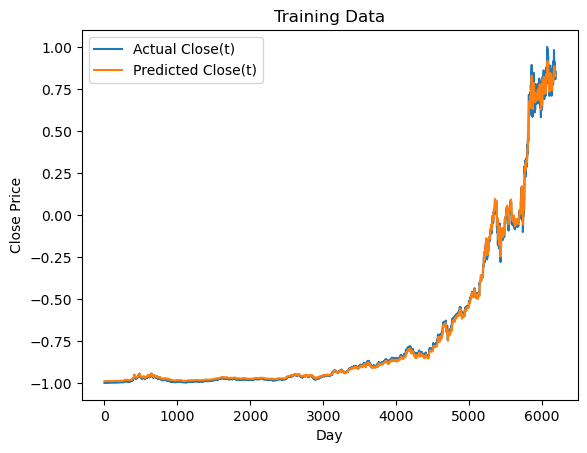

In [104]:
plt.plot(y_train, label='Actual Close(t)')
plt.plot(y_pred, label='Predicted Close(t)')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.title('Training Data')
plt.legend()

In [105]:
# Transform the training data to the original scale
train_predictions = y_pred.flatten()

dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = train_predictions
dummies = scaler.inverse_transform(dummies)

train_predictions = dc(dummies[:, 0])
train_predictions

array([  1.05279216,   1.05395937,   1.05378151, ..., 170.7766724 ,
       170.26441911, 170.30848391], shape=(6183,))

In [106]:
dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = y_train.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_train = dc(dummies[:, 0])
new_y_train

/var/folders/38/vqm_jnw91nq8j7r_g3t7rcz40000gp/T/ipykernel_25355/2550294898.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dummies[:, 0] = y_train.flatten()


array([7.91646265e-02, 7.65634249e-02, 7.52572660e-02, ...,
       1.69091505e+02, 1.73315001e+02, 1.68871003e+02], shape=(6183,))

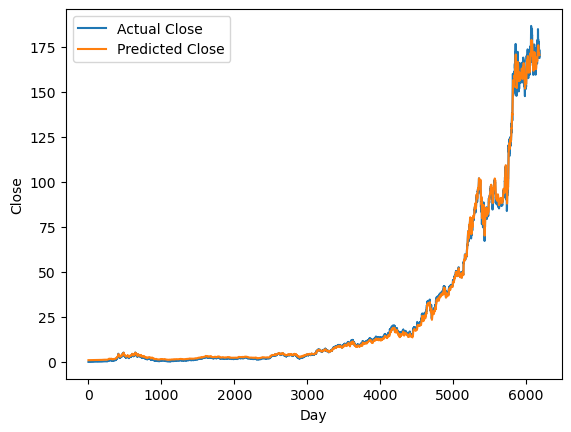

In [107]:
plt.plot(new_y_train, label='Actual Close')
plt.plot(train_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()


In [109]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = dc(dummies[:, 0])
#test_predictions

In [110]:
dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = y_test.flatten()
dummies = scaler.inverse_transform(dummies)

new_y_test = dc(dummies[:, 0])
#new_y_test

/var/folders/38/vqm_jnw91nq8j7r_g3t7rcz40000gp/T/ipykernel_25355/3197616979.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dummies[:, 0] = y_test.flatten()


Text(0.5, 1.0, 'Test Data')

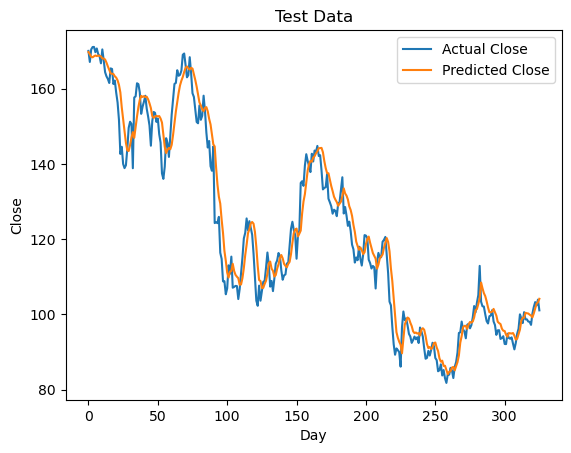

In [111]:
plt.plot(new_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.title('Test Data')

We can try increasing the number of stacked LSTM layers and see if the model performs better.